# Passing Network build up (Statsbomb data)

## 0. Setup

In [1]:
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from mplsoccer import Pitch

from statsbombpy import sb

from scipy.optimize import linear_sum_assignment

from tqdm import tqdm

warnings.filterwarnings("ignore",message="credentials not found, using statsbombpy's default credentials")

The length of the pitch is 120, width is 80

In [2]:
PITCH_X_MAX = 120
PITCH_Y_MAX = 80
MIN_STARTERS = 11
WATERMARK_NAME     = "Victoria Friss de Kereki"
WATERMARK_SUBTITLE = "Sports Analytics & Data Science"
FULL_MATCH_THRESHOLD = 100

## 1. Exploring Available Competitions

We extract all the male games from season 2015-2016 and later.

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

free_comps = sb.competitions()

comps = free_comps[free_comps["competition_gender"] == "male"].copy()

comps["season_start"]=comps["season_name"].str.split("/").str[0].astype(int)

comps = comps[comps["season_start"] >= 2015].copy()

In [4]:
match_counts = []

for comp_id, season_id in zip(comps["competition_id"], comps["season_id"]):
    try:
        matches = sb.matches(competition_id=comp_id, season_id=season_id)
        matches_count = len(matches)
    except:
        matches_count = 0

    match_counts.append({
        "competition_id": comp_id,
        "season_id": season_id,
        "matches_count": matches_count
    })

match_counts_df = pd.DataFrame(match_counts)

metadata_cols = ["competition_id", "season_id", "competition_name",
                 "season_name", "country_name"]

match_counts_df = match_counts_df.merge(
    comps[metadata_cols],
    on=["competition_id", "season_id"],
    how="left"
)

full_comps = match_counts_df[
    match_counts_df["matches_count"] >= FULL_MATCH_THRESHOLD
].sort_values("matches_count", ascending=False).reset_index(drop=True)

In [5]:
full_comps.head()

,competition_id,season_id,matches_count,competition_name,season_name,country_name
0,11,27,380,La Liga,2015/2016,Spain
1,12,27,380,Serie A,2015/2016,Italy
2,2,27,380,Premier League,2015/2016,England
3,7,27,377,Ligue 1,2015/2016,France
4,1238,108,115,Indian Super league,2021/2022,India


We use : **Bundesliga 2015/16**(`competition_id=9, season_id=27`), which contains 306 matches — enough to build meaningful season-level networks for all 18 teams. The match that we choose is *Der Klassiker* but Dortmund VS Leverkusen. 

In [6]:
comp = 9
season = 27

matches_df = sb.matches(competition_id=comp, season_id=season)

klassiker = matches_df[
    (
        (matches_df["home_team"] == "Bayer Leverkusen") &
        (matches_df["away_team"] == "Borussia Dortmund")
    )
    |
    (
        (matches_df["home_team"] == "Borussia Dortmund") &
        (matches_df["away_team"] == "Bayer Leverkusen")
    )
]

In [7]:
klassiker.head()

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_id,competition_country_name,competition_name,competition,season_id,season,home_team_id,home_team,home_team_gender,home_team_group,home_team_country_id,home_team_country_name,away_team_id,away_team,away_team_gender,away_team_group,away_team_country_id,away_team_country_name,competition_stage_id,competition_stage,stadium_id,stadium,stadium_country_id,stadium_country_name,referee_id,referee,referee_country_id,referee_country_name,home_managers,away_managers,home_manager_id,home_manager_name,home_manager_nickname,home_manager_dob,home_manager_country_id,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
12,3890456,2016-02-21,16:30:00.000,0,1,available,unscheduled,2023-07-15T21:48:00.266005,None,22,9,Germany,1. Bundesliga,Germany - 1. Bundesliga,27,2015/2016,904,Bayer Leverkusen,male,None,85,Germany,180,Borussia Dortmund,male,None,85,Germany,1,Regular Season,377,BayArena,85,Germany,241,Felix Zwayer,85,Germany,Roger Schmidt,Thomas Tuchel,3980,Roger Schmidt,None,1967-03-13,85,Germany,279,Thomas Tuchel,None,1973-08-29,85,Germany,1.1.0,2,2
29,3890301,2015-09-20,17:30:00.000,3,0,available,unscheduled,2023-07-12T17:40:05.681076,None,5,9,Germany,1. Bundesliga,Germany - 1. Bundesliga,27,2015/2016,180,Borussia Dortmund,male,None,85,Germany,904,Bayer Leverkusen,male,None,85,Germany,1,Regular Season,373,Signal-Iduna-Park,85,Germany,231,Deniz Aytekin,85,Germany,Thomas Tuchel,Roger Schmidt,279,Thomas Tuchel,None,1973-08-29,85,Germany,3980,Roger Schmidt,None,1967-03-13,85,Germany,1.1.0,2,2


## 2. Extracting and Saving the Pass Data

In [8]:
all_passes = []

for match_id in tqdm(matches_df["match_id"], desc="Extracting passes"):
    events = sb.events(match_id=match_id)
    passes = events[events["type"] == "Pass"].copy()
    passes["match_id"] = match_id
    all_passes.append(passes)

passes_df = pd.concat(all_passes, ignore_index=True)

Extracting passes: 100%|██████████| 34/34 [00:23<00:00,  1.44it/s]


In [9]:
passes_df.head()

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,miscontrol_aerial_won,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_deflected,pass_end_location,pass_goal_assist,pass_height,pass_length,pass_miscommunication,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_open_goal,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,dribble_no_touch,foul_committed_offensive,goalkeeper_shot_saved_to_post,pass_cut_back,pass_inswinging,shot_deflected,shot_saved_to_post,bad_behaviour_card,clearance_other,pass_no_touch,ball_recovery_offensive,goalkeeper_punched_out,pass_straight,shot_redirect,goalkeeper_shot_saved_off_target,shot_saved_off_target
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.623864,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,338032a5-de46-4b74-a5c0-771573c72847,5,NaN,NaN,"[60.0, 40.0]",3890563,0,NaN,NaN,NaN,NaN,-1.525373,NaN,Right Foot,NaN,NaN,"[60.1, 37.8]",NaN,Ground Pass,2.202272,NaN,NaN,NaN,Hakan Çalhanoğlu,7039.0,NaN,NaN,NaN,NaN,Kick Off,1,From Kick Off,Stefan Kießling,11394.0,Right Center Forward,2,Bayer Leverkusen,904,[79ccfb5b-3d71-4f00-8087-fd5c5779c41c],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bayer Leverkusen,904,00:00:00.700,Pass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.923506,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,e3d276d6-681e-4660-b186-d5157a13f20f,8,NaN,NaN,"[64.8, 31.3]",3890563,0,NaN,NaN,NaN,NaN,-2.402672,NaN,Right Foot,NaN,NaN,"[55.8, 23.1]",NaN,Ground Pass,12.175385,NaN,NaN,NaN,Kevin Kampl,8222.0,NaN,NaN,NaN,NaN,NaN,1,From Kick Off,Hakan Çalhanoğlu,7039.0,Left Center Forward,2,Bayer Leverkusen,904,[13d1f007-7e58-4d4b-80d6-ee535289e067],2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bayer Leverkusen,904,00:00:02.489,Pass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.164087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4823b3e2-9838-48cd-86d1-6fde8e6099c2,12,NaN,NaN,"[54.3, 26.5]",3890563,0,NaN,NaN,NaN,NaN,2.145764,NaN,Right Foot,NaN,NaN,"[38.1, 51.5]",NaN,Ground Pass,29.789930,NaN,NaN,NaN,André Ramalho Silva,9363.0,NaN,NaN,NaN,NaN,NaN,1,From Kick Off,Kevin Kampl,8222.0,Left Defensive Midfield,2,Bayer Leverkusen,904,"[b36f0ac2-419b-4358-af75-44c841c7102b, e00ea6b...",4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bayer Leverkusen,904,00:00:04.532,Pass,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.841929,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8f422a77-8241-4694-bf26-f962c237d731,15,NaN,NaN,"[40.9, 51.7]",3890563,0,NaN,NaN,NaN,NaN,-1.816793,NaN,Right Foot,NaN,NaN,"[

Save the passes csv. 

In [ ]:
matches_meta = matches_df[[
    "match_id", "match_date", "season", "competition",
    "home_team", "away_team", "home_score", "away_score"
]].copy()

passes_df = passes_df.merge(matches_meta, on="match_id", how="left")

passes_df.to_csv(
    
    "D:\桌面\passes_bundesliga_201516_statsbomb_all.csv", index=False)

## 3. Loading and Cleaning the Data

We need `location` and `pass_end_location` as the cleaned pass data. 

In [11]:
def clean_passes(passes_df: pd.DataFrame) -> pd.DataFrame:
    """Extract coordinates, remove invalid passes, and clip to pitch bounds."""

    passes = passes_df.copy()

    def _coords(col, idx):
        return col.apply(lambda v: v[idx] if isinstance(v, (list, tuple)) else None)

    passes["start_x"] = _coords(passes["location"], 0)
    passes["start_y"] = _coords(passes["location"], 1)
    passes["end_x"]   = _coords(passes["pass_end_location"], 0)
    passes["end_y"]   = _coords(passes["pass_end_location"], 1)

    passes = passes[passes["pass_outcome"] != "Injury Clearance"].copy()

    for col, max_val in [("start_x", PITCH_X_MAX), ("end_x", PITCH_X_MAX),
                         ("start_y", PITCH_Y_MAX), ("end_y", PITCH_Y_MAX)]:
        passes[col] = passes[col].clip(lower=0, upper=max_val)

    return passes

def load_passes(path: str) -> pd.DataFrame:
    """Load passes from a saved CSV and return
    a cleaned DataFrame ready for plotting."""

    import ast

    passes_df = pd.read_csv(
        path,
        low_memory=False,
        converters={
            "location":          lambda x: ast.literal_eval(x) if pd.notna(x) else None,
            "pass_end_location": lambda x: ast.literal_eval(x) if pd.notna(x) else None,
        }
    )

    return clean_passes(passes_df)

In [12]:
passes = load_passes(r"D:\桌面\passes_bundesliga_201516_statsbomb_all.csv")

In [13]:
passes.head()

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,miscontrol_aerial_won,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_deflected,pass_end_location,pass_goal_assist,pass_height,pass_length,pass_miscommunication,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_open_goal,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,dribble_no_touch,foul_committed_offensive,goalkeeper_shot_saved_to_post,pass_cut_back,pass_inswinging,shot_deflected,shot_saved_to_post,bad_behaviour_card,clearance_other,pass_no_touch,ball_recovery_offensive,goalkeeper_punched_out,pass_straight,shot_redirect,goalkeeper_shot_saved_off_target,shot_saved_off_target,match_date,season,competition,home_team,away_team,home_score,away_score,start_x,start_y,end_x,end_y
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.623864,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,338032a5-de46-4b74-a5c0-771573c72847,5,NaN,NaN,"[60.0, 40.0]",3890563,0,NaN,NaN,NaN,NaN,-1.525373,NaN,Right Foot,NaN,NaN,"[60.1, 37.8]",NaN,Ground Pass,2.202272,NaN,NaN,NaN,Hakan Çalhanoğlu,7039.0,NaN,NaN,NaN,NaN,Kick Off,1,From Kick Off,Stefan Kießling,11394.0,Right Center Forward,2,Bayer Leverkusen,904,['79ccfb5b-3d71-4f00-8087-fd5c5779c41c'],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bayer Leverkusen,904,00:00:00.700,Pass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-05-14,2015/2016,Germany - 1. Bundesliga,Bayer Leverkusen,Ingolstadt,3,2,60.0,40.0,60.1,37.8
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.923506,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,e3d276d6-681e-4660-b186-d5157a13f20f,8,NaN,NaN,"[64.8, 31.3]",3890563,0,NaN,NaN,NaN,NaN,-2.402672,NaN,Right Foot,NaN,NaN,"[55.8, 23.1]",NaN,Ground Pass,12.175385,NaN,NaN,NaN,Kevin Kampl,8222.0,NaN,NaN,NaN,NaN,NaN,1,From Kick Off,Hakan Çalhanoğlu,7039.0,Left Center Forward,2,Bayer Leverkusen,904,['13d1f007-7e58-4d4b-80d6-ee535289e067'],2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bayer Leverkusen,904,00:00:02.489,Pass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-05-14,2015/2016,Germany - 1. Bundesliga,Bayer Leverkusen,Ingolstadt,3,2,64.8,31.3,55.8,23.1
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.164087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4823b3e2-9838-48cd-86d1-6fde8e6099c2,12,NaN,NaN,"[54.3, 26.5]",3890563,0,NaN,NaN,NaN,NaN,2.145764,NaN,Right Foot,NaN,NaN,"[38.1, 51.5]",NaN,Ground Pass,29.789930,NaN,NaN,NaN,André Ramalho Silva,9363.0,NaN,NaN,NaN,NaN,NaN,1,From Kick Off,Kevin Kampl,8222.0,Left Defensive Midfield,2,Bayer Leverkusen,904,"['b36f0ac2-419b-4358-af75-44c841c7102b', 'e00e...",4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bayer Leverkusen,904,00:00:04.532,Pass,True,NaN,NaN,NaN,NaN,NaN,NaN,N

## 4. Helpers

Two small functions are used throughout the rest of the code and are worth defining upfront.

In [16]:
def _norm(x) -> str | None:
    """Lowercase and strip a player name for consistent matching."""
    return str(x).strip().lower() if pd.notna(x) else None

def format_nickname(name: str) -> str:
    """Capitalise each word of a name, preserving common particles."""
    if pd.isna(name):
        return name
    particles = {"de", "da", "del", "van", "von"}
    words = str(name).split()
    if all(w[0].isupper() or w.lower() in particles for w in words):
        return name
    return " ".join(w.lower() if w.lower() in particles else w.capitalize()
                    for w in words)

## 5. Building a Match-Level Network
A passing network for a single team in a single match requires two things: knowing who started, and knowing where each starter typically operated on the ball

- Get starting XI


In [18]:
def get_starting_xi(match_id: int,
                    team: str) -> pd.DataFrame | None:
    """Return a DataFrame with columns [player, nickname] for the starting XI."""
    
    try:
        lineup = sb.lineups(match_id=match_id)[team]
    except Exception:
        return None

    df = lineup.explode("positions")

    pos = pd.json_normalize(df["positions"])

    df = pd.concat(
        [df.drop(columns="positions").reset_index(drop=True), pos],
        axis=1
    )

    df["player"] = df["player_name"].apply(_norm)
    df["nickname"] = df["player_nickname"]
    df["from"] = df["from"].fillna("0:00")

    df = df.sort_values("from")

    starters = df.head(11)[["player", "nickname"]]

    return starters if len(starters) >= MIN_STARTERS else None

- Get average positions

In [19]:
def build_match_network(match_id: int, team: str, passes: pd.DataFrame):
    """
    Build average node positions for one team in one match.
    Returns (node_pos_df, pass_df, xi_df) or None if data is insufficient.
    """
    
    df = passes[
        (passes["match_id"] == match_id) & (passes["team"] == team)
    ].copy()

    if df.empty:
        return None

    df["p"] = df["player"].apply(_norm)
    df["r"] = df["pass_recipient"].apply(_norm)

    xi = get_starting_xi(match_id, team)

    if xi is None:
        return None

    starters = xi["player"].tolist()

    locs = pd.concat([
        df[df["p"].isin(starters)][["p", "start_x", "start_y"]].rename(
            columns={"p": "player", "start_x": "x", "start_y": "y"}
        ),
        df[df["r"].isin(starters)][["r", "end_x", "end_y"]].rename(
            columns={"r": "player", "end_x": "x", "end_y": "y"}
        ),
    ])

    avg = locs.groupby("player").agg(
        x=("x", "mean"),
        y=("y", "mean")
    ).reset_index()

    return (avg, df, xi) if len(avg) >= MIN_STARTERS else None

- Build edges

In [20]:
def build_edges(pass_df: pd.DataFrame,
                node_pos: pd.DataFrame) -> pd.DataFrame:
    """Aggregate pass counts between node pairs and attach coordinates."""

    edges = (
        pass_df.groupby(["p", "r"])
        .size()
        .reset_index(name="weight")
        .rename(columns={"p": "slot_from", "r": "slot_to"})
    )

    edges = edges[edges["slot_from"] != edges["slot_to"]]

    edges = (edges
             .merge(node_pos.rename(columns={"player": "slot_from",
                                             "x": "x_start",
                                             "y": "y_start"}),
                    on="slot_from")
             .merge(node_pos.rename(columns={"player": "slot_to",
                                             "x": "x_end",
                                             "y": "y_end"}),
                    on="slot_to"))

    return edges

## 6. Aligning Networks Across Matches

If we want to build a seasonal-level network, we can use the terms of position roles instead of players. To define manually the position of each player is more robust, but we can still use the first match as reference. 


In [21]:
def _align_nodes(match_nodes: list[pd.DataFrame],
                 reference: pd.DataFrame) -> list[pd.DataFrame]:
    """Use the Hungarian algorithm to align each match's nodes
    to a shared reference layout."""

    aligned = []

    for nodes in match_nodes:
        if len(nodes) < len(reference):
            continue
        cost = np.linalg.norm(
            nodes[["x", "y"]].values[:, None, :] -
            reference[["x", "y"]].values[None, :, :],
            axis=2
        )
        r, c = linear_sum_assignment(cost)
        nodes = nodes.iloc[r].copy()
        nodes["slot"] = c
        aligned.append(nodes)

    return aligned

## 7. Building a Season-Level Network

Aggrgate all the network to a seasonal level network.

In [26]:
def build_season_network(passes: pd.DataFrame, team: str, season: str):
    """
    Aggregate all match-level networks for a team into a season-level network.
    Returns (node_pos_df, edges_df) or None.
    """

    df = passes[(passes["team"] == team) & (passes["season"] == season)]
    if df.empty:
        return None

    match_ids = df["match_id"].dropna().unique()
    match_nodes, match_passes, xi_list = [], [], []

    for m in match_ids:
        res = build_match_network(m, team, passes)
        if res is None:
            continue
        nodes, match_df, xi = res
        match_nodes.append(nodes)
        match_passes.append(match_df)
        xi_list.append(xi)

    if not match_nodes:
        return None

    reference = match_nodes[0].copy()
    reference["slot"] = range(len(reference))

    aligned = _align_nodes(match_nodes, reference)

    if not aligned:
        return None

    nodes_df = pd.concat(aligned, ignore_index=True)

    # Average position per slot
    node_pos = (nodes_df.groupby("slot")
            .agg(x=("x", "mean"), y=("y", "mean"))
            .reset_index())
    
    # Build nickname map from all lineups
    xi_all = pd.concat(xi_list, ignore_index=True)
    nickname_map = (
        xi_all.dropna(subset=["nickname"])
        .drop_duplicates("player")
        .set_index("player")["nickname"]
        .to_dict()
    )

    players = nodes_df["player"].unique()
    slots   = sorted(nodes_df["slot"].unique())
    matrix  = np.zeros((len(players), len(slots)))
    p_idx   = {p: i for i, p in enumerate(players)}
    s_idx   = {s: i for i, s in enumerate(slots)}

    counts = nodes_df.groupby(["player", "slot"]).size().reset_index(name="n")

    for _, row in counts.iterrows():
        matrix[p_idx[row["player"]], s_idx[row["slot"]]] = row["n"]

    r_ind, c_ind = linear_sum_assignment(-matrix)
    slot_to_player = {slots[j]: players[i] for i, j in zip(r_ind, c_ind)}

    node_pos["player"] = node_pos["slot"].map(slot_to_player)

    node_pos["label"]  = (node_pos["player"]
                          .map(nickname_map)
                          .fillna(node_pos["player"])
                          .apply(format_nickname))
    
    player_to_slot = nodes_df.groupby("player")["slot"].agg(lambda x: x.mode()[0])

    all_passes = pd.concat(match_passes, ignore_index=True)
    all_passes["slot_from"] = all_passes["p"].map(player_to_slot)
    all_passes["slot_to"]   = all_passes["r"].map(player_to_slot)

    edges = (
        all_passes.groupby(["slot_from", "slot_to"])
        .size()
        .reset_index(name="weight")
        .dropna()
    )

    edges = edges[edges["slot_from"] != edges["slot_to"]]

    edges = (edges
             .merge(node_pos, left_on="slot_from", right_on="slot")
             .merge(node_pos, left_on="slot_to", right_on="slot",
                    suffixes=("_start", "_end")))

    return node_pos, edges

## 8. Draw the Network

In [27]:
def _draw_network(ax, pitch, node_pos: pd.DataFrame, edges: pd.DataFrame,
                  node_size: int = 240, label_size: int = 8,
                  watermark: bool = False) -> None:
    """Draw nodes and weighted edges onto an existing pitch axis."""
    pitch.draw(ax=ax)

    if edges is not None and not edges.empty:
        max_w = edges["weight"].max()
        for _, r in edges.iterrows():
            pitch.lines(
                r.x_start, r.y_start, r.x_end, r.y_end,
                lw=(r["weight"] / max_w) * 6,
                color="red",
                alpha=0.3 + (r["weight"] / max_w) * 0.6,
                ax=ax, zorder=1
            )
    pitch.scatter(node_pos.x, node_pos.y,
                  s=node_size, color="blue", edgecolor="black",
                  linewidth=1.2, ax=ax, zorder=3)
    label_col = "label" if "label" in node_pos.columns else "player"
    for _, r in node_pos.iterrows():
        ax.text(r.x, r.y, format_nickname(r[label_col]),
                ha="center", va="center",
                fontsize=label_size, fontweight="bold",
                bbox=dict(facecolor="white", alpha=0.6,
                          edgecolor="none", boxstyle="round,pad=0.2"),
                zorder=4)
    if watermark:
        ax.text(PITCH_X_MAX - 1, 75.5, WATERMARK_NAME,
                ha="right", va="bottom",
                fontsize=10, color="#888888",
                zorder=5)
        ax.text(PITCH_X_MAX - 1, 79, WATERMARK_SUBTITLE,
                ha="right", va="bottom",
                fontsize=9, color="#aaaaaa",
                zorder=5)

## 9. Responsive Grid Layout

In [30]:
def _make_grid(n_items: int, n_cols: int):
    """Return (fig, axes_list, node_size, label_size, title_size)
    for a responsive grid."""

    if n_items == 1:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        return fig, [ax], 400, 10, 16

    if n_items == 2:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        return fig, list(axes), 320, 13, 14

    n_rows = int(np.ceil(n_items / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))

    return fig, list(axes.flatten()), 240, 8, 12

In [31]:
def _draw_grid(results: list, main_title: str, n_cols: int = 4) -> None:
    """Render a list of (subtitle, node_pos, edges) tuples in a responsive grid."""

    if not results:
        print("No valid results.")
        return

    fig, axes, node_size, label_size, title_size = _make_grid(len(results), n_cols)

    pitch = Pitch(pitch_type="statsbomb", line_color="black", linewidth=2)

    inside_watermark = len(results) <= 2

    for i, (subtitle, node_pos, edges) in enumerate(results):
        _draw_network(axes[i], pitch, node_pos, edges, node_size, label_size,
                      watermark=inside_watermark)
        if subtitle:
            axes[i].set_title(
                subtitle, fontsize=title_size,
                fontweight="bold", pad=0.95)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(main_title, fontsize=18, fontweight="bold", y=0.95)

    plt.subplots_adjust(left=0.03, right=0.97, top=0.93,
                        bottom=0.03, wspace=0.02, hspace=0.1)

    if not inside_watermark:
        fig.text(0.94, 0.045, WATERMARK_NAME,
                 ha="right", fontsize=11, color="#888888")
        fig.text(0.94, 0.040, WATERMARK_SUBTITLE,
                 ha="right", fontsize=9.5, color="#aaaaaa")

    plt.show()

## 10. Putting It All Together

In [32]:
def plot_network(
    passes: pd.DataFrame,
    team: str = None,
    season: str = None,
    match_id: int = None,
    match_level: bool = False,
    n_cols: int = 4
) -> None:
    """
    Universal entry point for all passing network plots.
    Parameters
    ----------
    passes      : Cleaned passes DataFrame (output of load_passes).
    team        : Team name. None = all teams (season view).
    season      : Season string e.g. "2015/2016".
    match_id    : If provided (and match_level=False), plots both teams 
                  for that match.
    match_level : If True with a team, plots every match for that team 
                  in a grid.
    n_cols      : Number of columns for grid layouts.
    """

    # Single match - both teams side by side
    if match_id is not None and not match_level:
        _plot_single_match(match_id, passes)
        return

    # All matches for one team
    if match_level and team is not None:
        _plot_team_matches(passes, team, season, n_cols)
        return

    # Season view - one team or all teams
    teams = [team] if team else sorted(
        passes[passes["season"] == season]["team"].dropna().unique()
    )
    results = []
    for t in teams:
        res = build_season_network(passes, t, season)
        if res is not None:
            subtitle = "" if team else t
            results.append((subtitle, *res))
    title = (f"{team} Passing Network - {season}"
             if team else f"Passing Networks by Team - {season}")
    _draw_grid(results, title, n_cols)

In [33]:
def _plot_single_match(match_id: int, passes: pd.DataFrame) -> None:
    """Plot passing networks for both teams in a single match."""
    row = passes[passes["match_id"] == match_id].iloc[0]
    home, away  = row["home_team"], row["away_team"]
    score       = f"{row['home_score']}–{row['away_score']}"
    date        = pd.to_datetime(row["match_date"]).strftime("%d %b %Y")
    comp        = str(row.get("competition", "")).split(". ", 1)[-1]
    season      = row.get("season", "")
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    pitch = Pitch(pitch_type="statsbomb", line_color="black", linewidth=2)
 
    for ax, team in zip(axes, [home, away]):
        res = build_match_network(match_id, team, passes)
        if res is None:
            ax.axis("off")
            continue
 
        node_pos, match_df, _ = res
        edges = build_edges(match_df, node_pos)
 
        # Mirror the away team so both attack left-to-right
        if team == away:
            node_pos = node_pos.copy()
            edges    = edges.copy()
            node_pos["x"] = PITCH_X_MAX - node_pos["x"]
            node_pos["y"] = PITCH_Y_MAX - node_pos["y"]
            for col in ("x_start", "x_end"):
                edges[col] = PITCH_X_MAX - edges[col]
            for col in ("y_start", "y_end"):
                edges[col] = PITCH_Y_MAX - edges[col]
 
        _draw_network(ax, pitch, node_pos, edges, node_size=300, label_size=8,
                      watermark=True)
        ax.set_title(team, fontsize=13, fontweight="bold")
 
    fig.suptitle(f"{home} {score} {away}", fontsize=16, fontweight="bold", y=0.98)

    plt.figtext(0.5, 0.915, f"{date}  •  {comp}  ({season})",
                ha="center", fontsize=12, color="gray")
    plt.tight_layout()
    plt.show()

In [34]:
def _plot_team_matches(
        passes: pd.DataFrame, team: str,
        season: str, n_cols: int) -> None:

    """Plot a match-level grid for every game a team played in a season."""

    df = passes[(passes["team"] == team) & (passes["season"] == season)]

    match_ids = df.sort_values("match_date")["match_id"].dropna().unique()

    results = []

    for m in match_ids:
        res = build_match_network(m, team, passes)
        if res is None:
            continue
        node_pos, match_df, _ = res
        edges = build_edges(match_df, node_pos)
        row      = passes[passes["match_id"] == m].iloc[0]
        opponent = row["away_team"] if row["home_team"] == team else row["home_team"]
        score    = f"{row['home_score']}–{row['away_score']}"
        date     = pd.to_datetime(row["match_date"]).strftime("%d %b %Y")
        results.append((f"{opponent} ({score})\n{date}", node_pos, edges))

    row  = passes[passes["team"] == team].iloc[0]

    comp = str(row.get("competition", "")).split(". ", 1)[-1]

    _draw_grid(results, f"{team} - Match Networks  ({comp}  {season})", n_cols)

## Tryout

In [35]:
passes = load_passes(r"D:\桌面\passes_bundesliga_201516_statsbomb_all.csv")

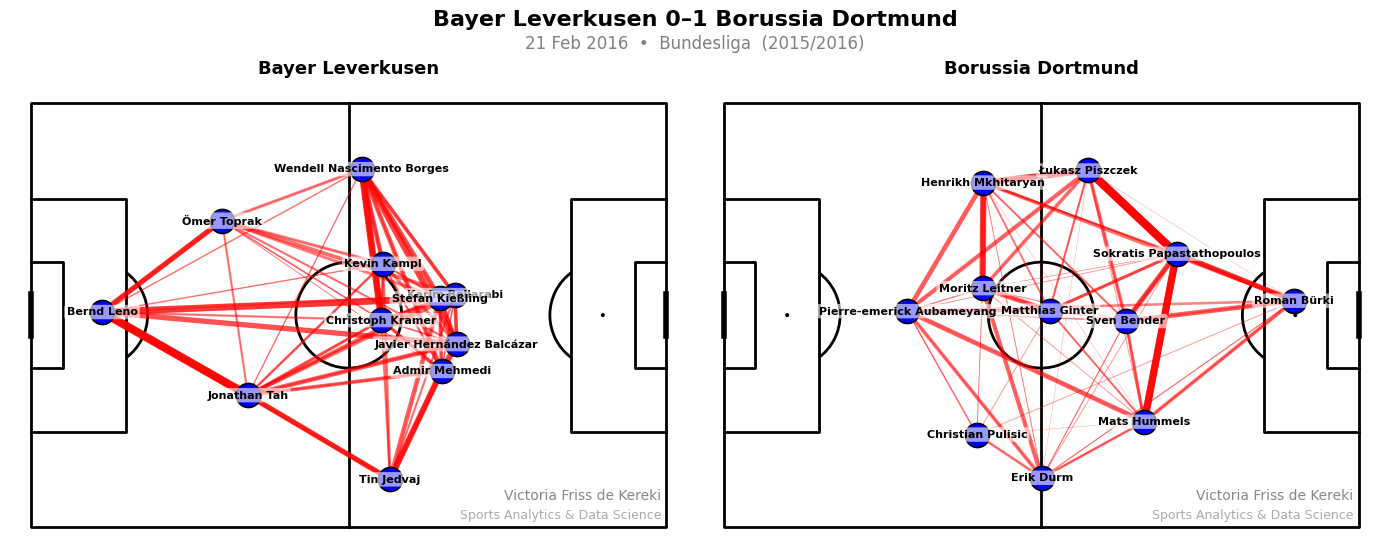

In [37]:
plot_network(passes, match_id=3890456)

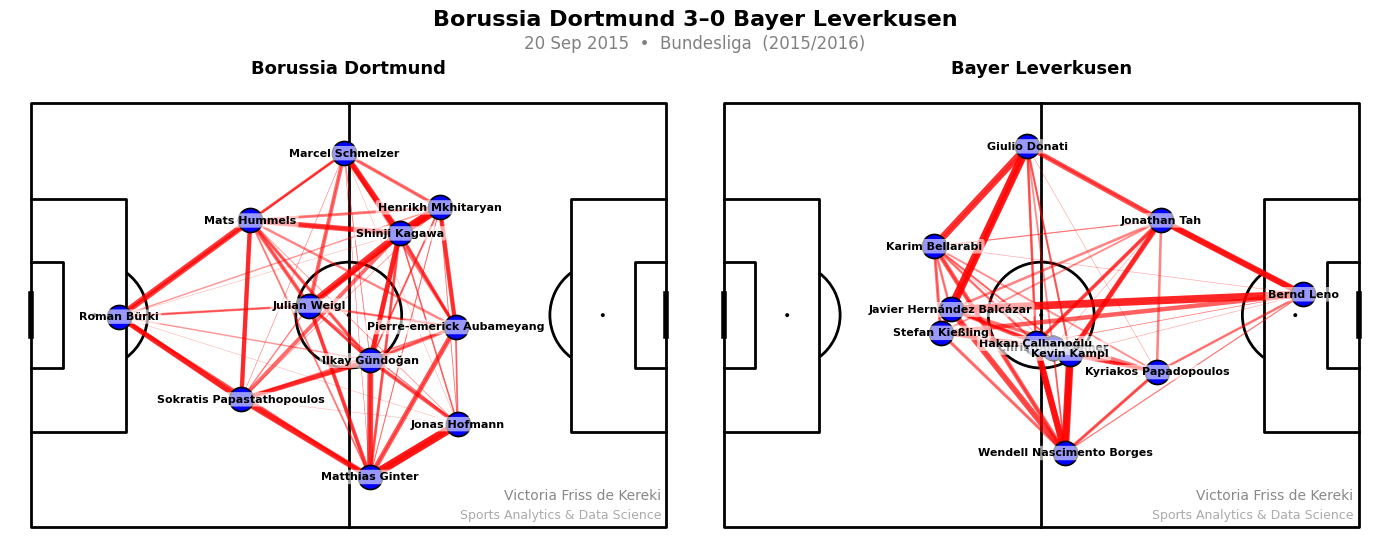

In [38]:
plot_network(passes, match_id=3890301)

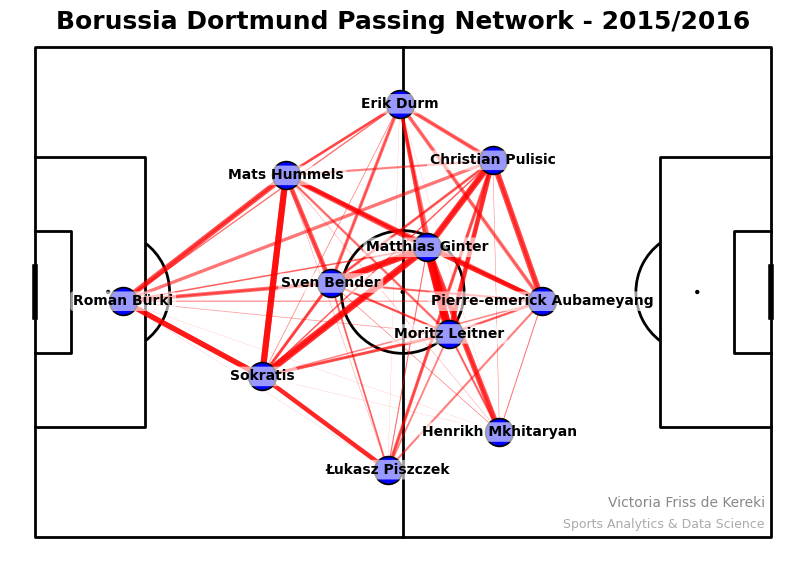

In [40]:
plot_network(passes, team="Borussia Dortmund", season="2015/2016")

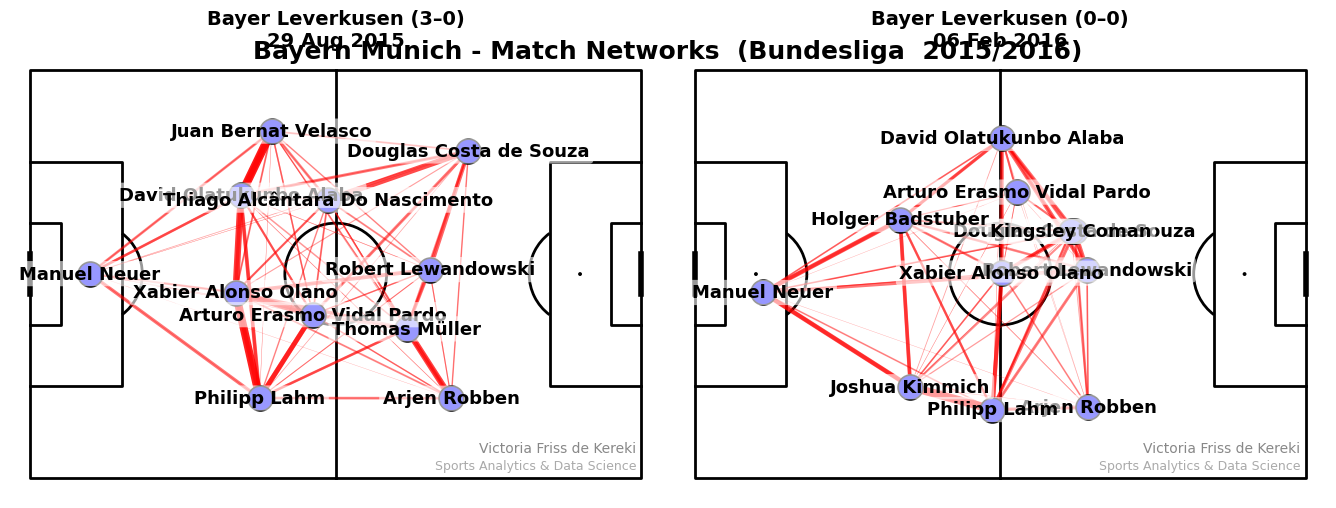

In [ ]:
plot_network(passes, team="Borussia Dortmund", season="2015/2016",
             match_level=True, n_cols=3)